<a href="https://colab.research.google.com/github/rafael76-lab/CNN_Pytorch/blob/main/CNN_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
transform= transforms.ToTensor()

In [ ]:
train_data= datasets.MNIST(root='cnn_data', train=True, download=True, transform=transform)

In [ ]:
test_data= datasets.MNIST(root='cnn_data', train=False, download=True, transform=transform)

In [ ]:
class Model(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=6)
        self.pool = nn.MaxPool2d(4)
        self.fc = nn.Linear(800, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def predict(self, x):
        logits = self.forward(x)
        probs = F.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1)
        return pred

In [ ]:
torch.manual_seed(123)
model= Model()
optimizer= torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn= nn.CrossEntropyLoss()
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

In [ ]:
losses = []
c= 0
for epoch in range(2):

    for xb, yb in train_loader:

        logits = model(xb)

        loss = loss_fn(logits, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

        if len(losses) % 1000 == 0:

            a = np.mean(losses[-1000:])

            print(
                f"Loss promedio últimos 1000 batches: {a:.4f}")
        if epoch > c:
            c= epoch
            print(c)


Loss promedio últimos 1000 batches: 0.3115
1
Loss promedio últimos 1000 batches: 0.1075
Loss promedio últimos 1000 batches: 0.0770


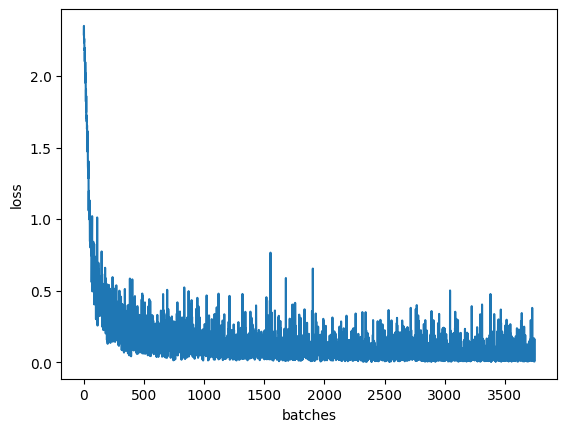

In [ ]:
plt.plot(losses)
plt.xlabel("batches")
plt.ylabel("loss")
plt.show()

In [ ]:
x_test = test_data.data.float().unsqueeze(1) / 255.0
y_test = test_data.targets
x_train = train_data.data.float().unsqueeze(1) / 255.0
y_train = train_data.targets
model.eval()
with torch.no_grad():
    pred = model.predict(x_test)
    predt= model.predict(x_train)

scoretest = accuracy_score(y_test.numpy(), pred.numpy())
scoretrain = accuracy_score(y_train.numpy(), predt.numpy())
print(f"El accuracy en el test data es {scoretest}.")
print(f"El accuracy en el train data es {scoretrain}.")

El accuracy en el test data es 0.9831.
El accuracy en el train data es 0.9830666666666666.


In [ ]:
#Modelo aleatorio
moda = stats.mode(y_test.numpy()).mode
pred_moda = np.full(len(y_test), moda)
score_moda  = accuracy_score(y_test.numpy(), pred_moda)
print(score_moda)

0.1135


La etiqueta es 9, y la predicción es 9


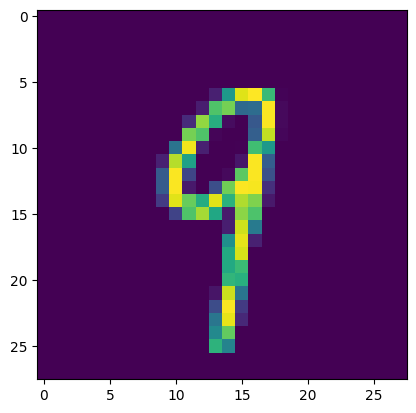

In [ ]:
t=train_data[900][0].view(1,1,28,28)
with torch.no_grad():
  g= model.predict(t)
plt.imshow(train_data[900][0].view(28,28))
print(f"La etiqueta es {train_data[900][1]}, y la predicción es {g.item()}")